# Final project

- Use firstly the Dataloader to load the csv and clean the original data
- then use DataVisualizer to visualize the data
- later use TextAnalyzer to do the sentimental analysis

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Warnings
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

from ecomm_review_analyzer.data_loader import DataLoader


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [168]:
file_path = "data/Womens Clothing E-Commerce Reviews.csv"

loader = DataLoader()

df = (loader.load_data(file_path)
            .clean_data()
            .show_summary()
            .process_ecommerce_data()
            .show_summary()
            .df)


Total Rows: 23486 | Total Columns: 10

--- Column Summary ---


,Data Type,Unique Values,Missing Values
Clothing ID,int64,1206,0
Age,int64,77,0
Title,object,13993,3810
Review Text,object,22634,845
Rating,int64,5,0
Recommended IND,int64,2,0
Positive Feedback Count,int64,82,0
Division Name,object,3,14
Department Name,object,6,14
Class Name,object,20,14



--- Data Sample (First 3 rows) ---


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses


Data processing complete.
Removed 846 records.
Final data shape: (22640, 12)
Total Rows: 22640 | Total Columns: 12

--- Column Summary ---


,Data Type,Unique Values,Missing Values
Clothing ID,int64,1179,0
Age,int64,77,0
Title,object,13993,0
Review Text,object,22634,0
Rating,int64,5,0
Recommended IND,int64,2,0
Positive Feedback Count,int64,82,0
Division Name,object,3,13
Department Name,object,6,13
Class Name,object,20,13



--- Data Sample (First 3 rows) ---


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,title_with_review,Age Group
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful - silky and sexy and com...,30-39
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Love this dress! it's sooo pretty. i happen...,30-39
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Some major design flaws I had such high hopes ...,60-69


In [169]:
for col in ['Age', 'Rating',
       'Recommended IND', 'Division Name',
       'Department Name', 'Class Name', 'Age Group']:
    print(f"{col}: {df[col].unique()}\n")

Age: [33 34 60 50 47 49 39 24 53 44 41 32 55 31 28 46 21 36 65 29 38 59 40 23
 67 48 43 52 56 66 61 57 58 37 27 62 68 51 83 69 54 63 71 30 64 42 35 22
 26 72 25 45 74 70 20 80 93 82 77 85 73 78 79 19 76 84 75 89 81 90 94 86
 99 18 91 87 92]

Rating: [4 5 3 2 1]

Recommended IND: [1 0]

Division Name: ['Initmates' 'General' 'General Petite' nan]

Department Name: ['Intimate' 'Dresses' 'Bottoms' 'Tops' 'Jackets' 'Trend' nan]

Class Name: ['Intimates' 'Dresses' 'Pants' 'Blouses' 'Knits' 'Outerwear' 'Lounge'
 'Sweaters' 'Skirts' 'Fine gauge' 'Sleep' 'Jackets' 'Swim' 'Trend' 'Jeans'
 'Legwear' 'Shorts' 'Layering' nan 'Casual bottoms' 'Chemises']

Age Group: ['30-39' '60-69' '50-59' '40-49' '20-29' '80-89' '70-79' '90-99' '10-19']



In [170]:
from ecomm_review_analyzer.data_visualizer import DataVisualizer

viz = DataVisualizer(df)

<Figure size 640x480 with 0 Axes>

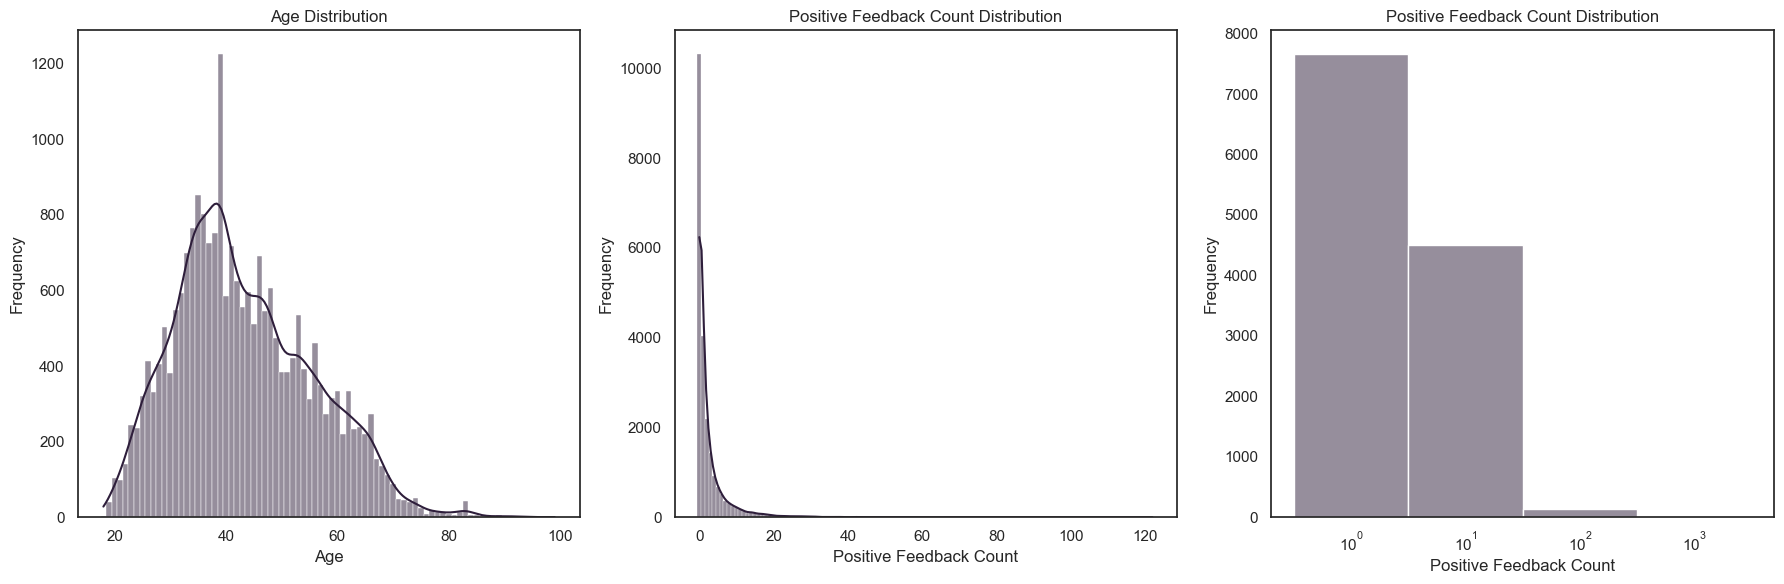

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

viz.plot_histogram(column_name="Age", ax=axes[0])

viz.plot_histogram(column_name="Positive Feedback Count", ax=axes[1])

viz.plot_histogram(
    column_name="Positive Feedback Count",
    ax=axes[2],
    log_scale=True
)

plt.tight_layout()
plt.show()

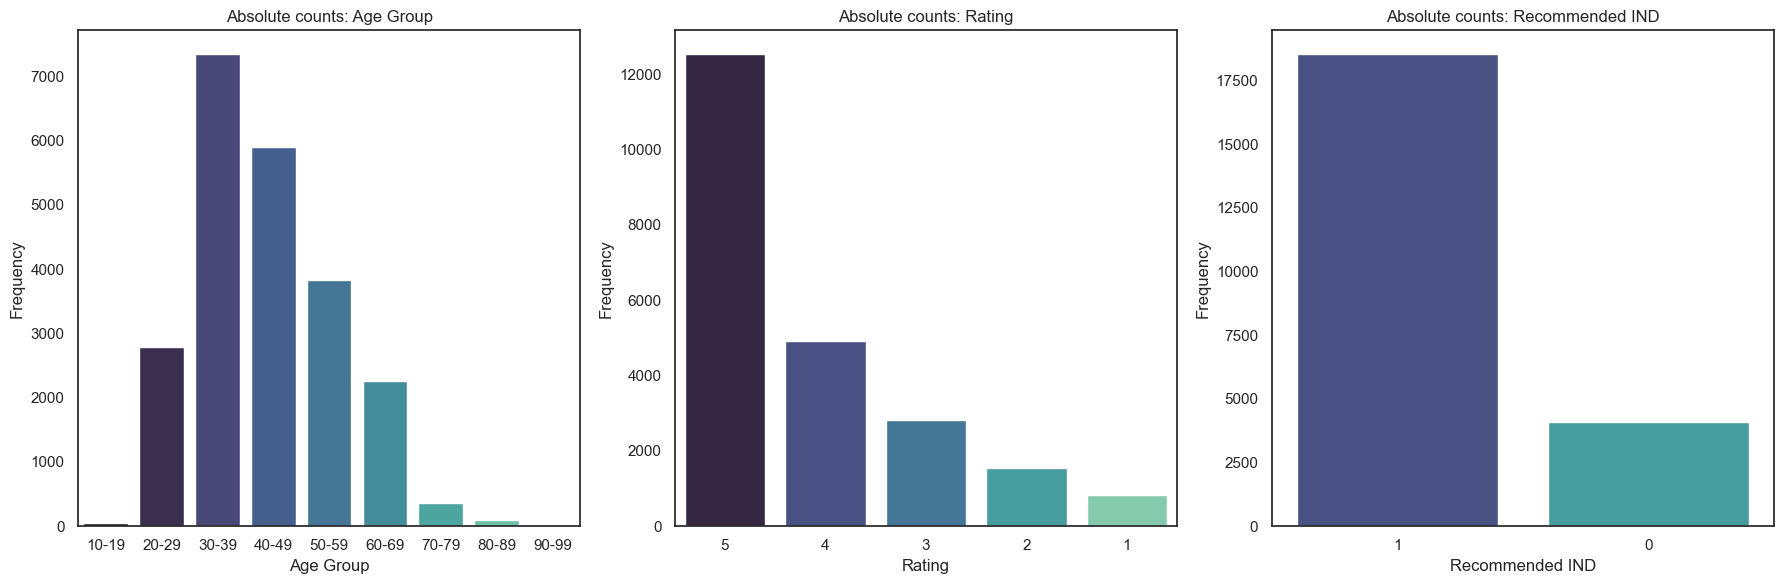

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

viz.plot_bar_chart(column_name="Age Group", orientation="v", sort_by_index=True, ax=axes[0])
viz.plot_bar_chart(column_name="Rating", orientation="v", ax=axes[1])
viz.plot_bar_chart(column_name="Recommended IND", orientation="v", ax=axes[2])

plt.tight_layout()
plt.show()

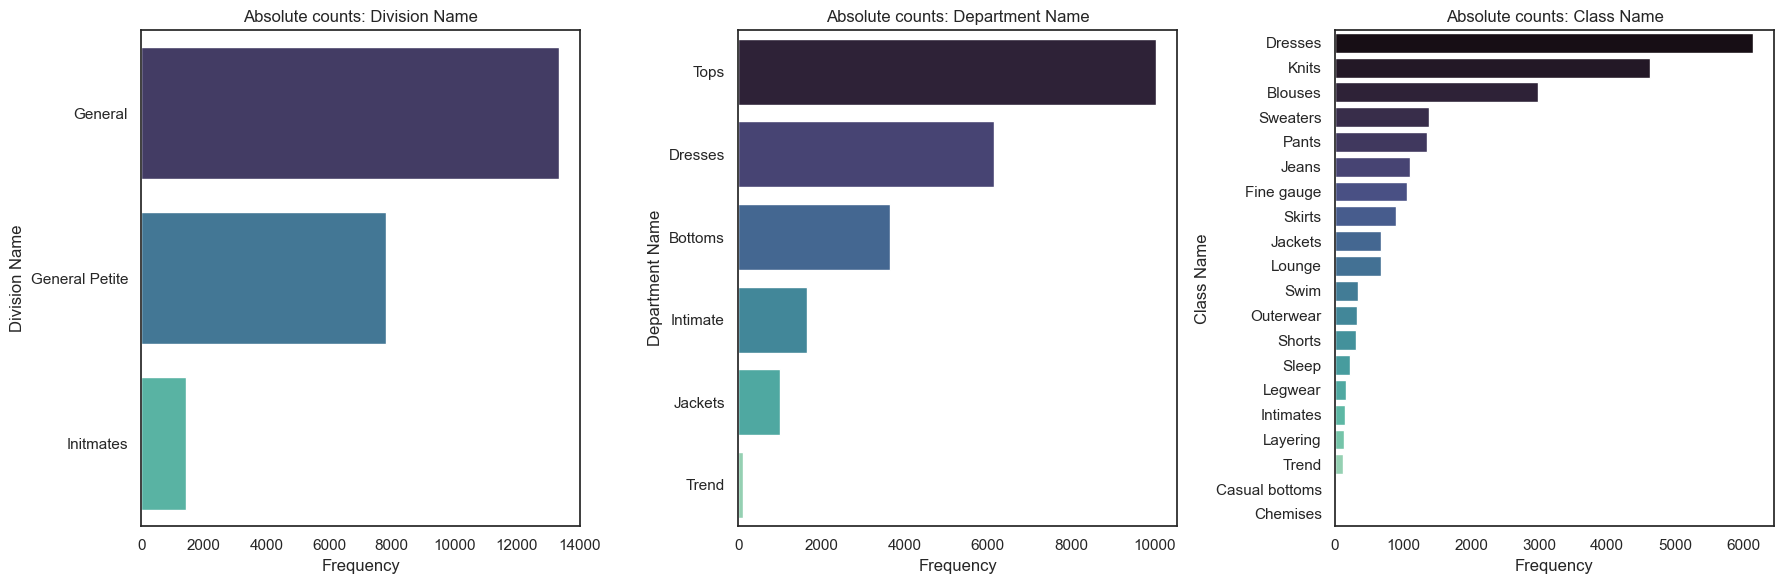

In [173]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

viz.plot_bar_chart(column_name="Division Name", ax=axes[0])
viz.plot_bar_chart(column_name="Department Name", ax=axes[1])
viz.plot_bar_chart(column_name="Class Name", ax=axes[2])

plt.tight_layout()
plt.show()

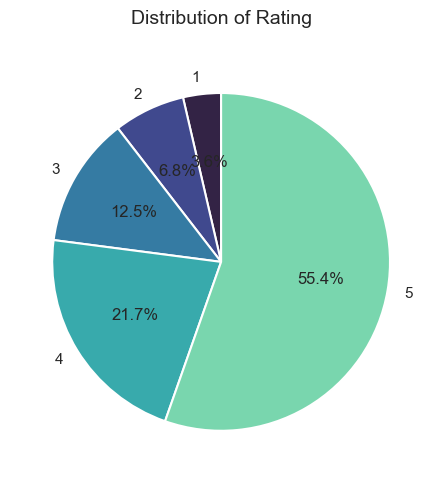

In [174]:
viz.plot_general_pie_chart(column_name="Rating")

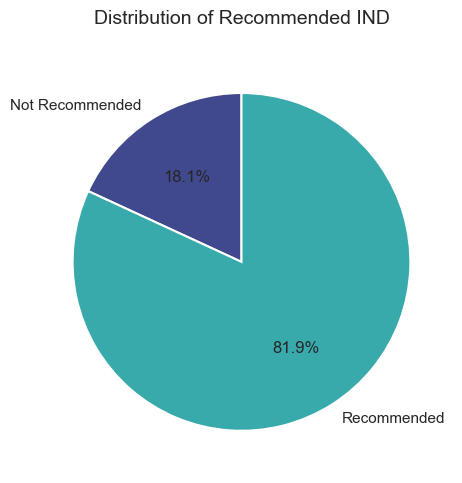

In [175]:
viz.plot_general_pie_chart(column_name="Recommended IND", labels=[ "Not Recommended", "Recommended"])

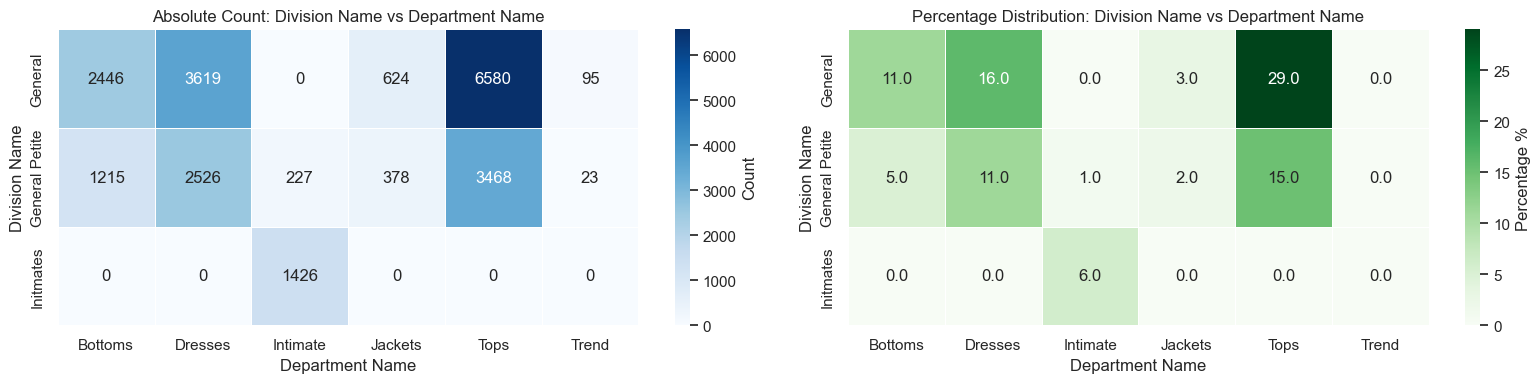

In [176]:
viz.plot_heatmap_comparison(row_col="Division Name", col_col="Department Name")

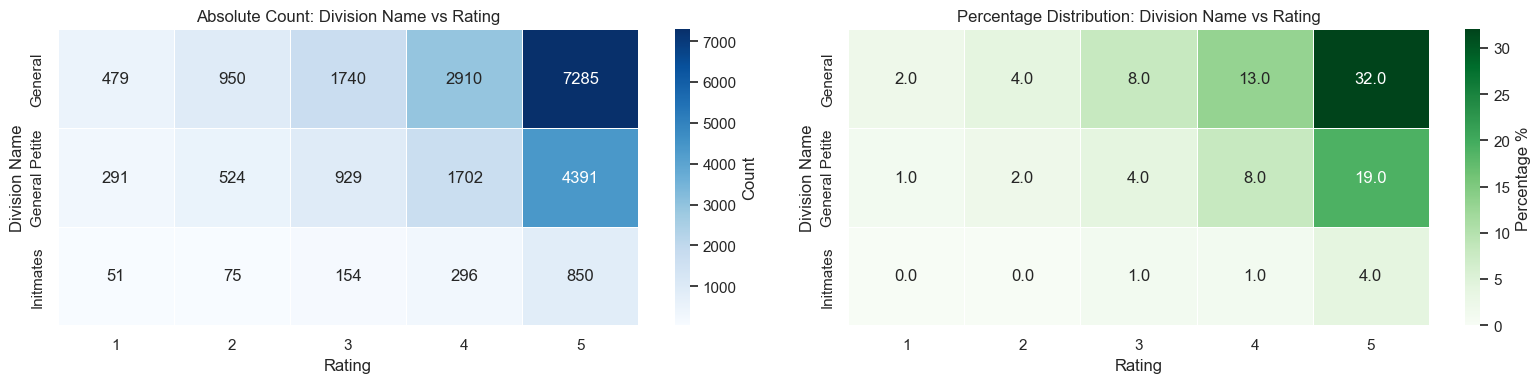

In [177]:
viz.plot_heatmap_comparison(row_col="Division Name", col_col="Rating")

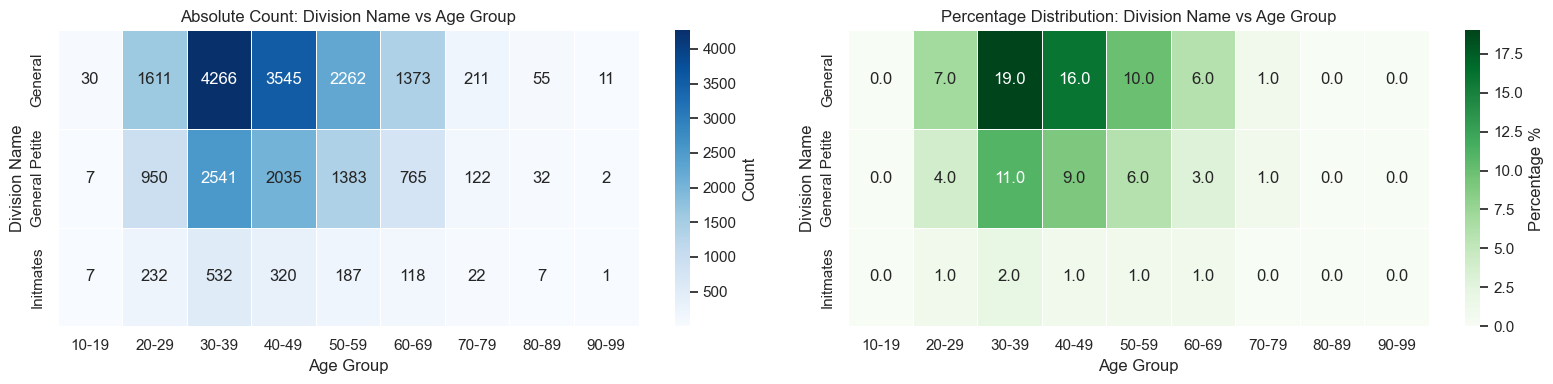

In [178]:
viz.plot_heatmap_comparison(row_col="Division Name", col_col="Age Group")

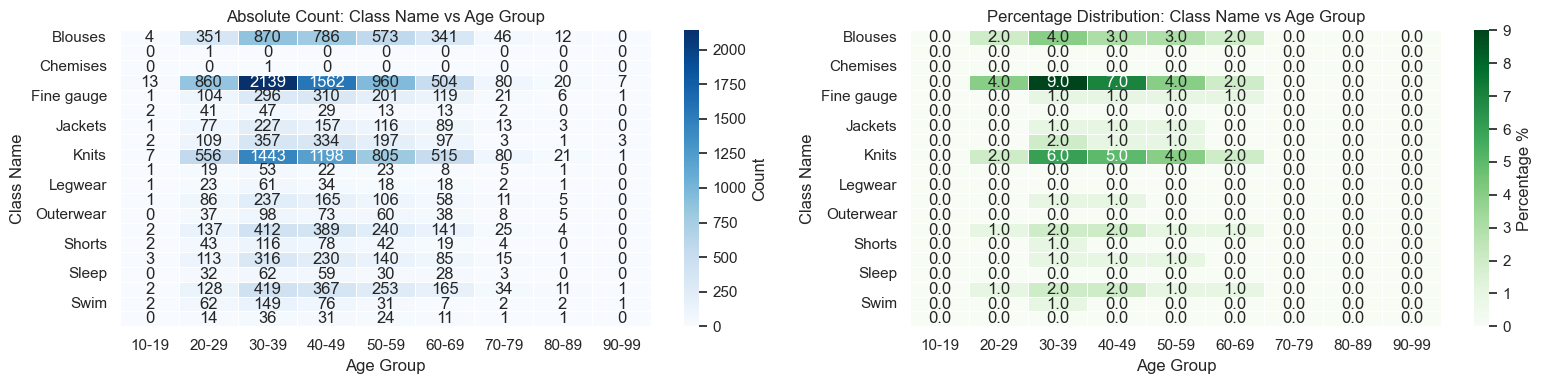

In [179]:
viz.plot_heatmap_comparison(row_col="Class Name", col_col="Age Group")

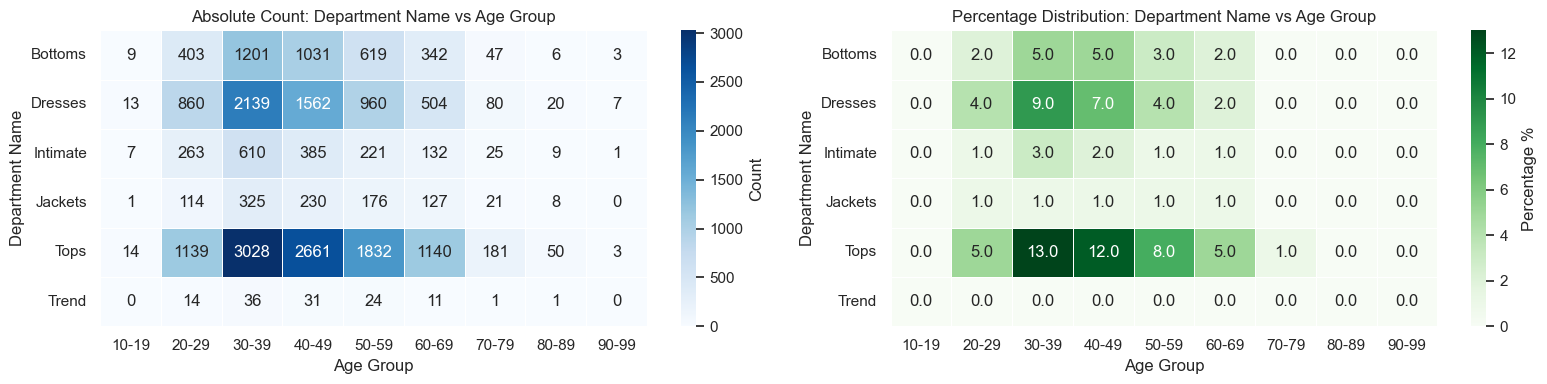

In [180]:
viz.plot_heatmap_comparison(row_col="Department Name", col_col="Age Group")

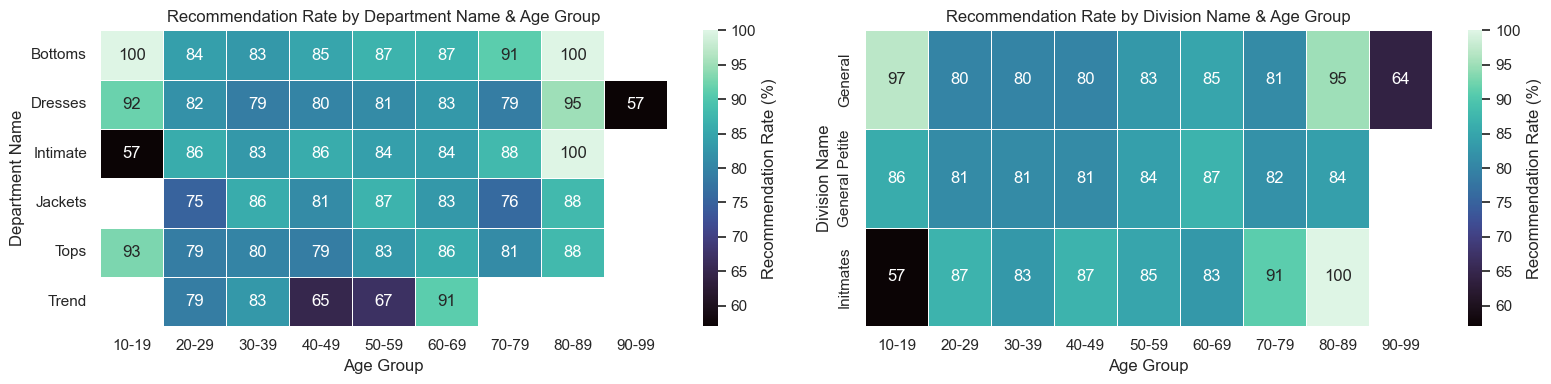

In [181]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

viz.plot_recommendation_rate_heatmap(row_col="Department Name", col_col="Age Group", values_col="Recommended IND", ax=ax[0])
viz.plot_recommendation_rate_heatmap(row_col="Division Name", col_col="Age Group", values_col="Recommended IND", ax=ax[1])

fig.tight_layout()
plt.show()

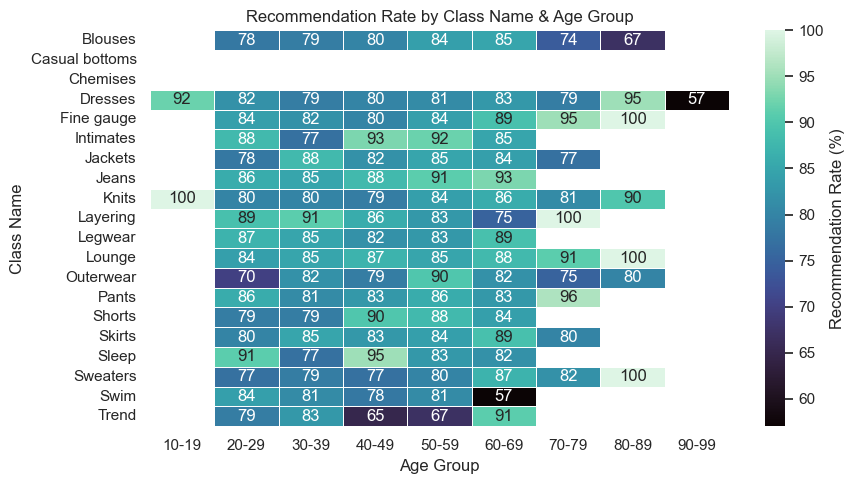

In [182]:
viz.plot_recommendation_rate_heatmap(row_col="Class Name", col_col="Age Group", values_col="Recommended IND")

In [183]:
from ecomm_review_analyzer.text_analyzer import TextAnalyzer
text_viz = TextAnalyzer(df)

text_viz.analyze_sentiment_vader()

Sentiment analysis complete.


<Figure size 640x480 with 0 Axes>

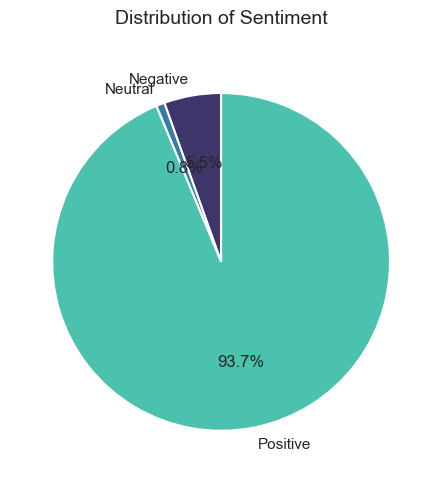

In [184]:
text_viz.plot_general_pie_chart(column_name="Sentiment")

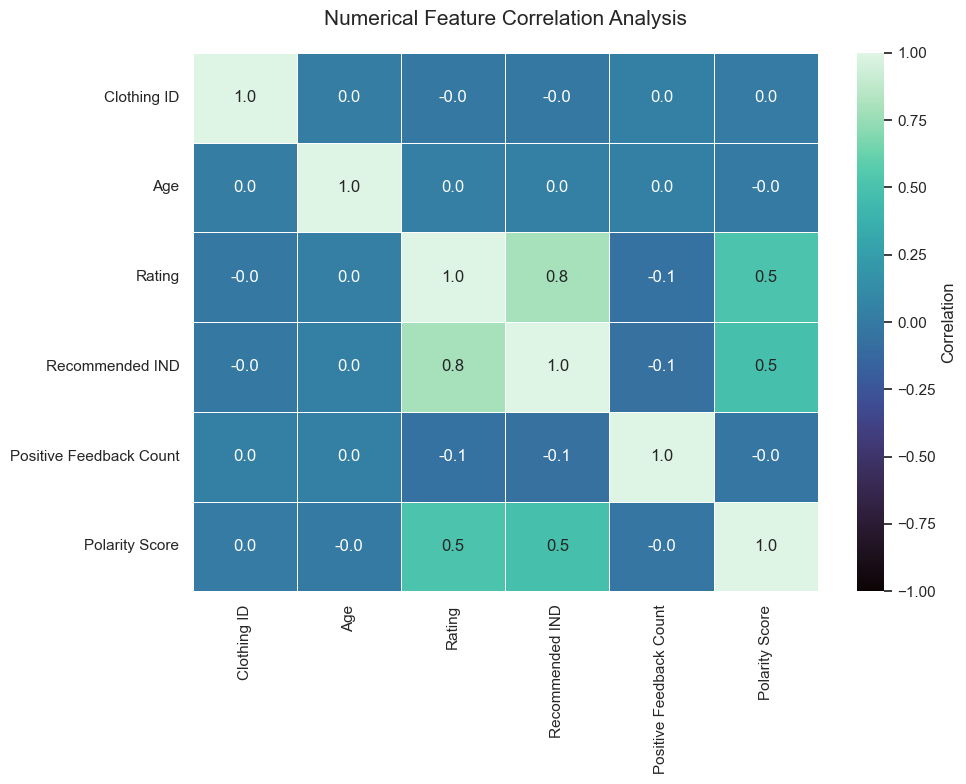

In [185]:
text_viz.plot_correlation_heatmap()

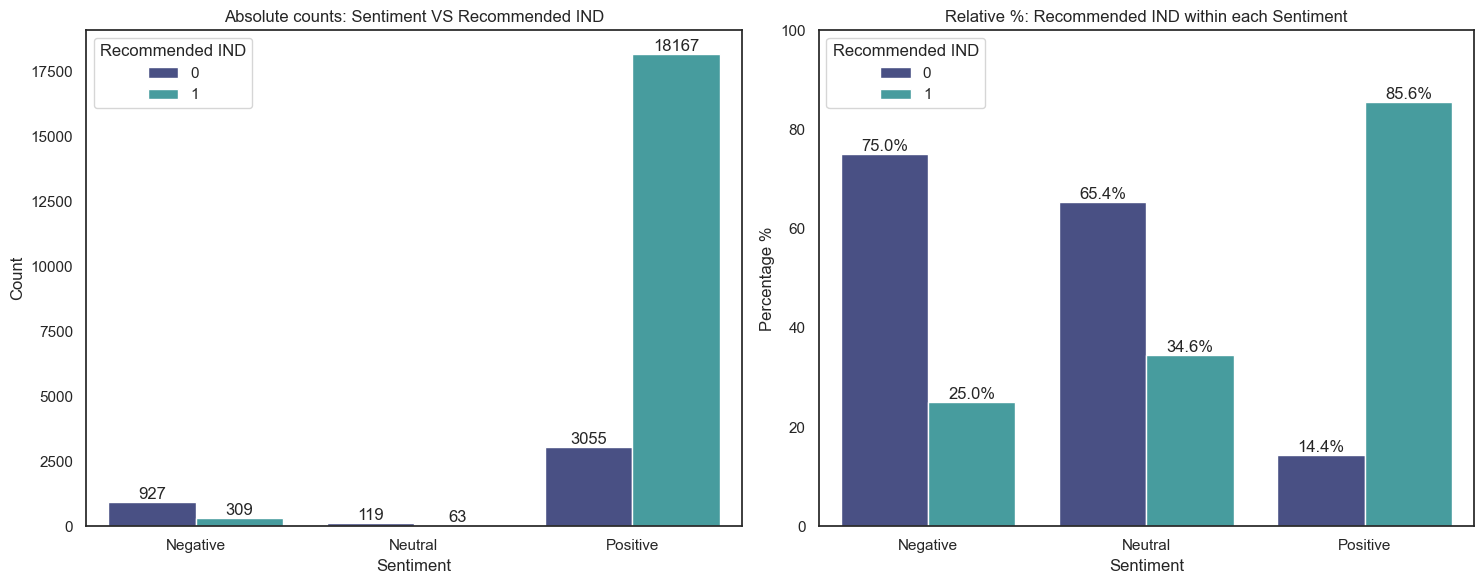

In [186]:
text_viz.plot_sentiment_vs_recommendations(x="Sentiment", hue="Recommended IND", order=["Negative","Neutral","Positive"])

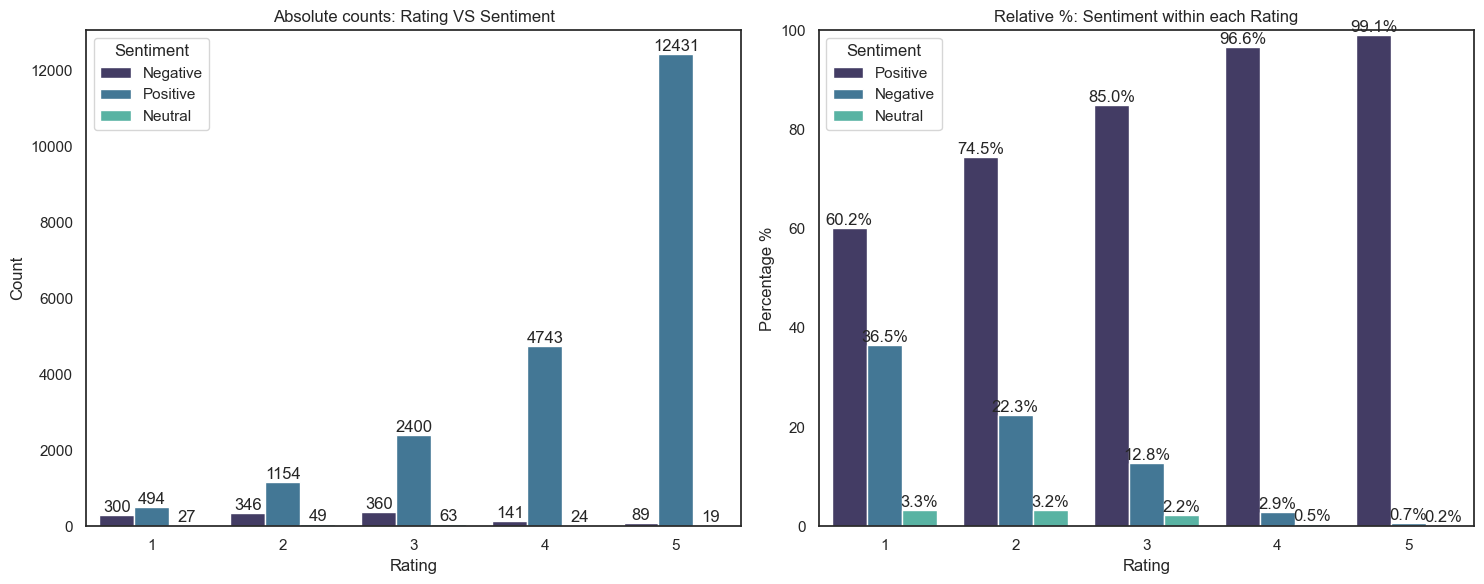

In [187]:
text_viz.plot_sentiment_vs_recommendations(x="Rating", hue="Sentiment")

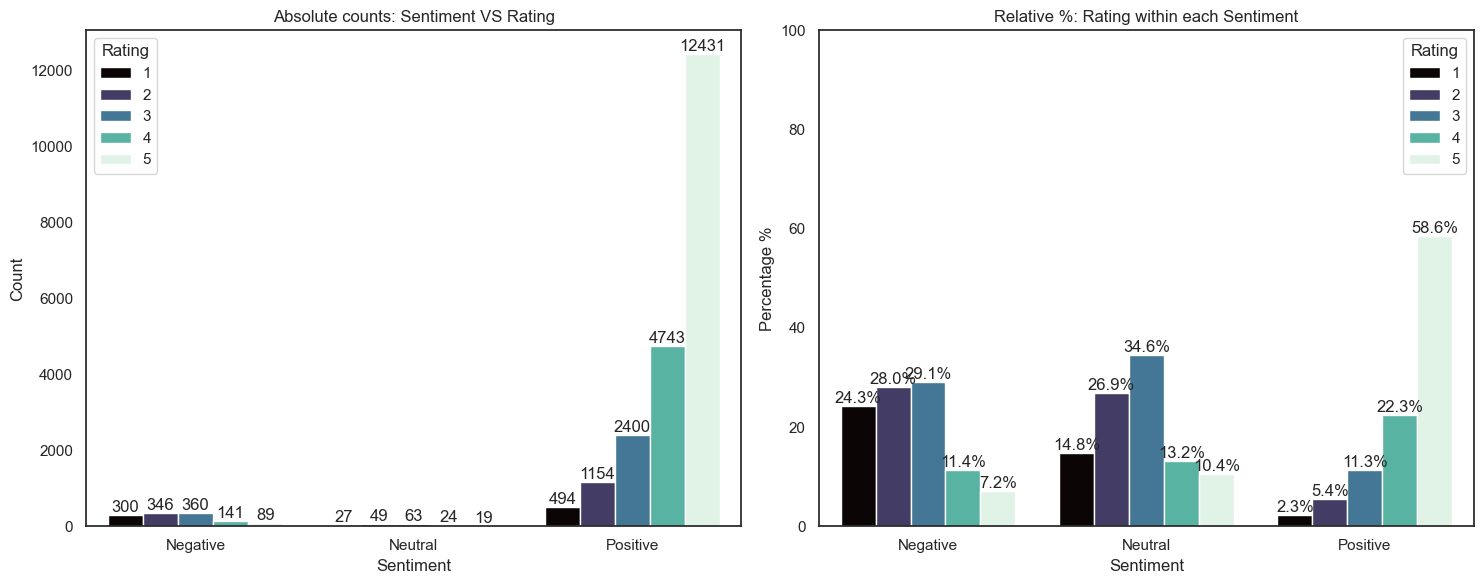

In [188]:
text_viz.plot_sentiment_vs_recommendations(x="Sentiment", hue="Rating", order=["Negative","Neutral","Positive"])

In [189]:
my_stopwords = text_viz.get_stopwords(extra_words=["dress", "petite", "made", "will"])

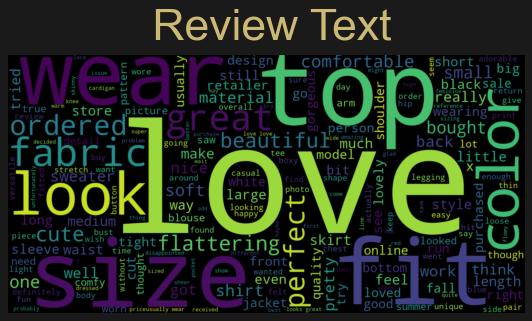

In [190]:
text_viz.plot_wordcloud(sentiment=None, stopwords=my_stopwords)

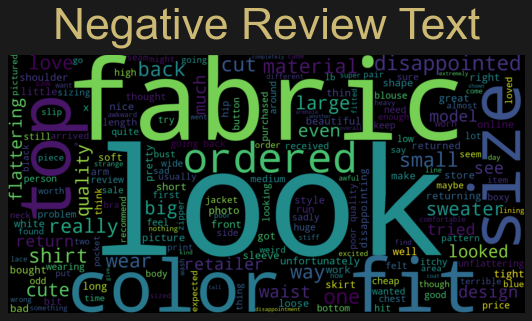

In [191]:
text_viz.plot_wordcloud(sentiment="Negative", stopwords=my_stopwords)

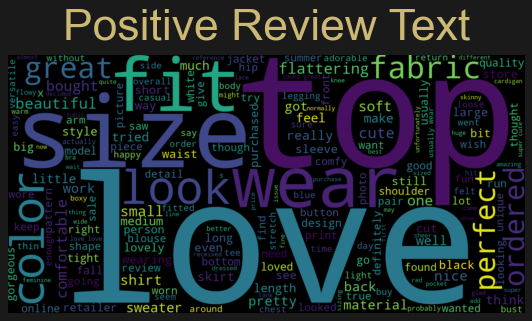

In [192]:
text_viz.plot_wordcloud(sentiment="Positive", stopwords=my_stopwords)

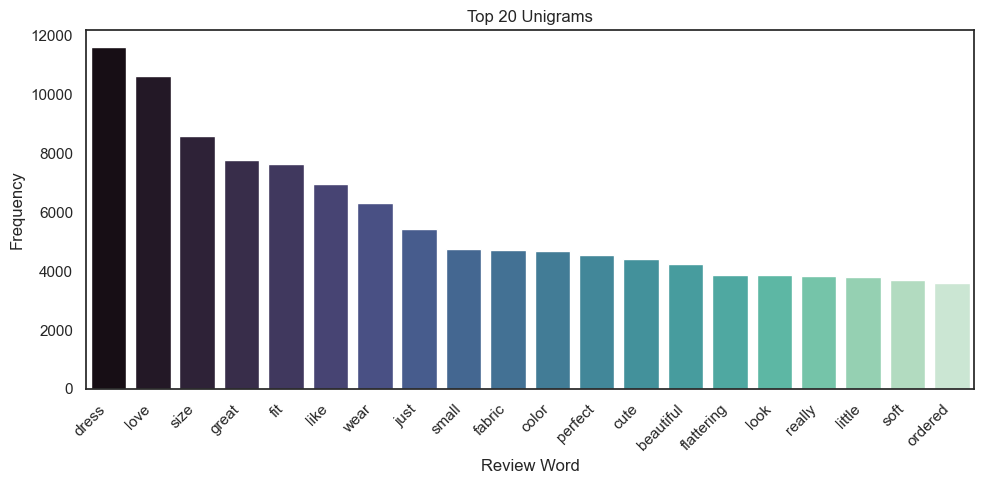

In [193]:
text_viz.plot_top_ngrams(ngram=1, sentiment="Positive")

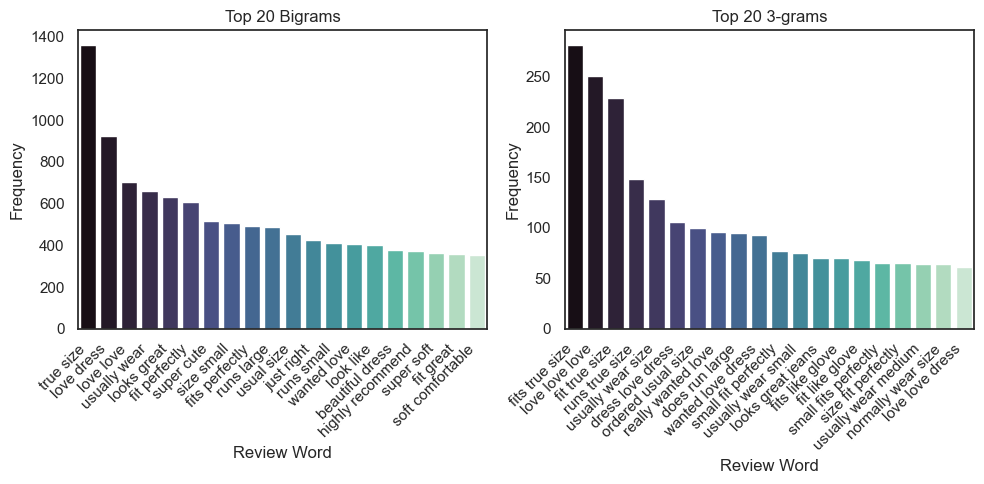

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

text_viz.plot_top_ngrams(ngram=2, sentiment="Positive", ax=axes[0])
text_viz.plot_top_ngrams(ngram=3, sentiment="Positive", ax=axes[1])

plt.tight_layout()
plt.show()

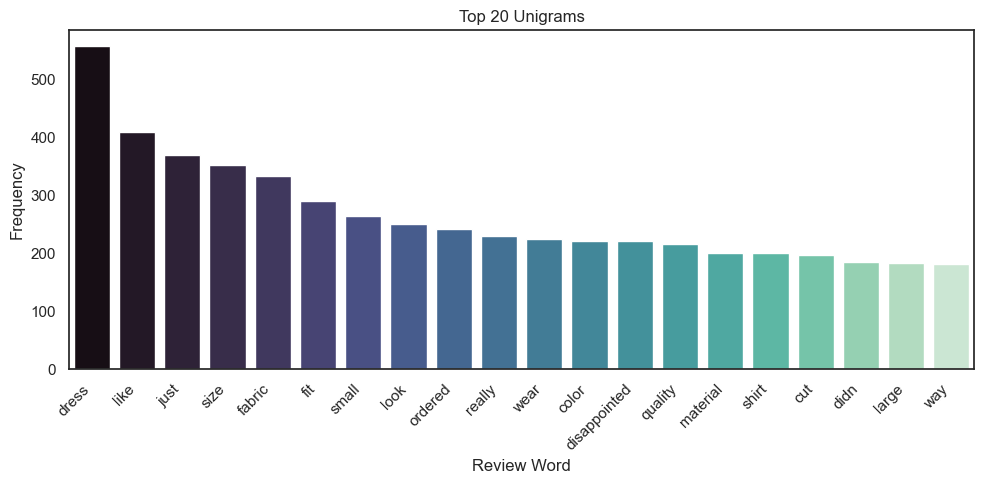

In [195]:
text_viz.plot_top_ngrams(ngram=1, sentiment="Negative")

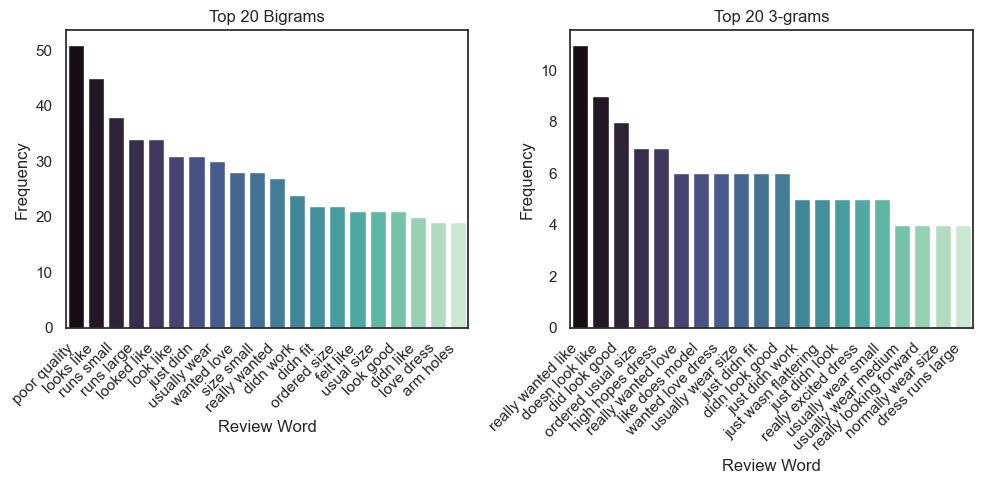

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

text_viz.plot_top_ngrams(ngram=2, sentiment="Negative", ax=axes[0])
text_viz.plot_top_ngrams(ngram=3, sentiment="Negative", ax=axes[1])

plt.tight_layout()
plt.show()